In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import pickle
import os
import sys
from time import time
from tqdm import tqdm
from matplotlib.patches import Patch

## Stastistial Analysis

In [6]:
all_features = [
    'capital-gain', 'age', 'hours-per-week', 'fnlwgt', 'occupation',
    'marital-status', 'relationship', 'education-num', 'education',
    'workclass', 'native-country', 'race', 'sex', 'capital-loss'
]

raw_data = {
    'MONICE(Multiobjective)': [94.8, 62.8, 50.5, 46.7, 31.2, 20.0, 20.0, 18.4, 13.3,  8.8,  8.4,  7.6,  4.2,  3.2],
    'MONICE(HEOM)':           [96.7, 60.4, 53.3, 46.4, 29.3, 20.4, 19.4, 20.0, 13.6,  9.1,  8.0,  6.5,  4.1,  4.0],
    'MONICE(SparsProx)':      [96.6,  5.9, 10.7, 44.2,  3.5,  2.3,  0.8,  5.6,  0.0,  0.0,  1.5,  0.4,  0.0,  0.5],
    'MONICE(ProxPlaus)':      [94.0, 52.7, 37.0, 42.5, 24.1, 12.6, 17.4, 12.8, 12.4,  7.7,  9.2,  5.6,  1.5,  1.3],
    'MONICE(SparsPlaus)':     [89.5, 42.3, 29.4, 29.6, 33.1, 14.9, 22.2, 13.5, 16.9, 11.0, 11.0,  9.2,  3.1,  0.9],
    'NICE(none)':             [93.0, 95.6, 57.0,100.0, 28.5, 13.9, 20.3, 15.8, 15.8,  4.4, 12.0,  7.0,  3.2,  1.9],
    'DiCE':                   [82.1,  6.5,  9.0,  7.8,  3.9,  2.6,  4.1,  7.1,  4.4,  4.4,  4.1,  3.4,  1.4, 14.2], 
    'DiCE-Extended':          [100.0,94.8, 64.4,100.0, 74.3, 35.8, 40.4, 48.8, 52.0, 30.4, 17.8, 20.0, 18.3,  3.4],
    'MOC':                    [100.0,28.2, 15.9, 17.7,  8.3, 33.1,  7.0, 18.6, 15.9,  9.1, 24.0,  3.5,  8.6,  8.8],
    'GeCo':                   [100.0,94.4, 65.6,100.0, 76.1, 38.8, 41.2, 52.0, 56.5, 31.0, 16.4, 21.4, 20.5,  1.9],
    'LIME':                   [100.0,12.7, 31.6,  0.0, 24.7, 82.3, 19.6, 48.7,  1.9,  3.2, 17.7,  0.0,  0.0,  0.0],
}

df_all = pd.DataFrame(raw_data, index=all_features)


KEY_METHODS = [
    'MONICE(Multiobjective)', 'MONICE(SparsProx)', 'MONICE(ProxPlaus)', 'MONICE(SparsPlaus)',
    'NICE(none)', 'DiCE', 'DiCE-Extended', 'MOC', 'GeCo', 'LIME'
]



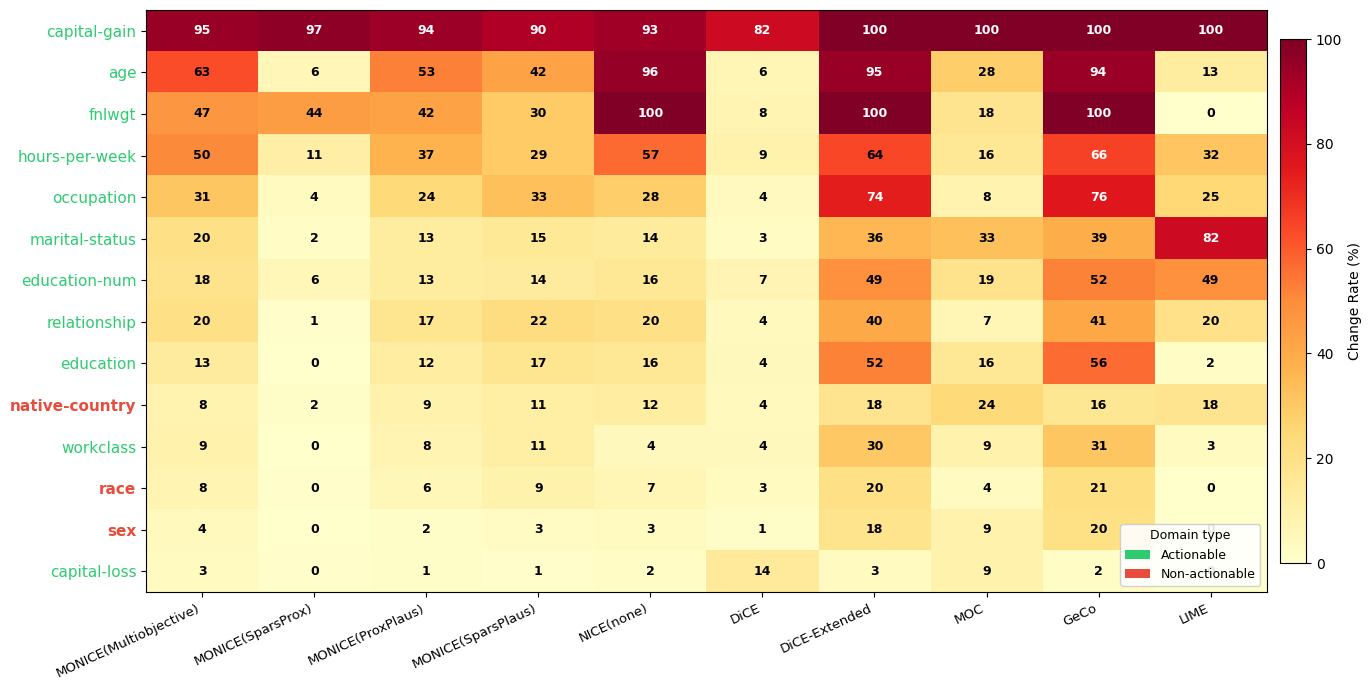

In [ ]:
IMMUTABLE  = ['sex', 'race', 'native-country']
MONOTONIC  = ['age', 'education-num']

ACTIONABLE = ['capital-gain', 'hours-per-week', 'fnlwgt', 'occupation',
              'education', 'workclass', 'capital-loss', 'marital-status', 'relationship']

NON_ACTIONABLE = IMMUTABLE

def get_domain_color(feat):
    if feat in NON_ACTIONABLE: return '#e74c3c'
    return '#2ecc71'


df_key = df_all[KEY_METHODS]
top_order = df_key.mean(axis=1).sort_values(ascending=False).index.tolist()

df_heat = df_key.loc[top_order]

fig, ax = plt.subplots(figsize=(15, 7))
Z = df_heat.values

im = ax.imshow(Z, cmap='YlOrRd', aspect='auto', vmin=0, vmax=100)

ax.set_xticks(range(len(KEY_METHODS)))
ax.set_xticklabels(KEY_METHODS, fontsize=9.5, rotation=25, ha='right')
ax.set_yticks(range(len(top_order)))
yticklabels = ax.set_yticklabels(top_order, fontsize=11)
for lbl in yticklabels:
    feat = lbl.get_text()
    lbl.set_color(get_domain_color(feat))
    if feat in NON_ACTIONABLE:
        lbl.set_fontweight('bold')

for i in range(len(top_order)):
    for j in range(len(KEY_METHODS)):
        val = Z[i, j]
        txt_color = 'white' if val >= 65 else 'black'
        ax.text(j, i, f'{val:.0f}', ha='center', va='center',
                fontsize=9, color=txt_color, fontweight='bold')

plt.colorbar(im, ax=ax, label='Change Rate (%)', shrink=0.9, pad=0.01)
# ax.set_title('Feature Change Rates\n'
#              '(Adult Dataset, ANN, Class 0->1: ≤50K -- >50K)',
#              fontsize=13, pad=14)

legend_handles = [
    Patch(facecolor='#2ecc71', label='Actionable'),
    Patch(facecolor='#e74c3c', label='Non-actionable'),
]
ax.legend(handles=legend_handles, fontsize=9, loc='lower right',
          bbox_to_anchor=(1.0, 0.0), framealpha=0.9,
          title='Domain type', title_fontsize=9)

plt.tight_layout()
plt.show()

Sensitive features sorted: ['native-country', 'race', 'sex']


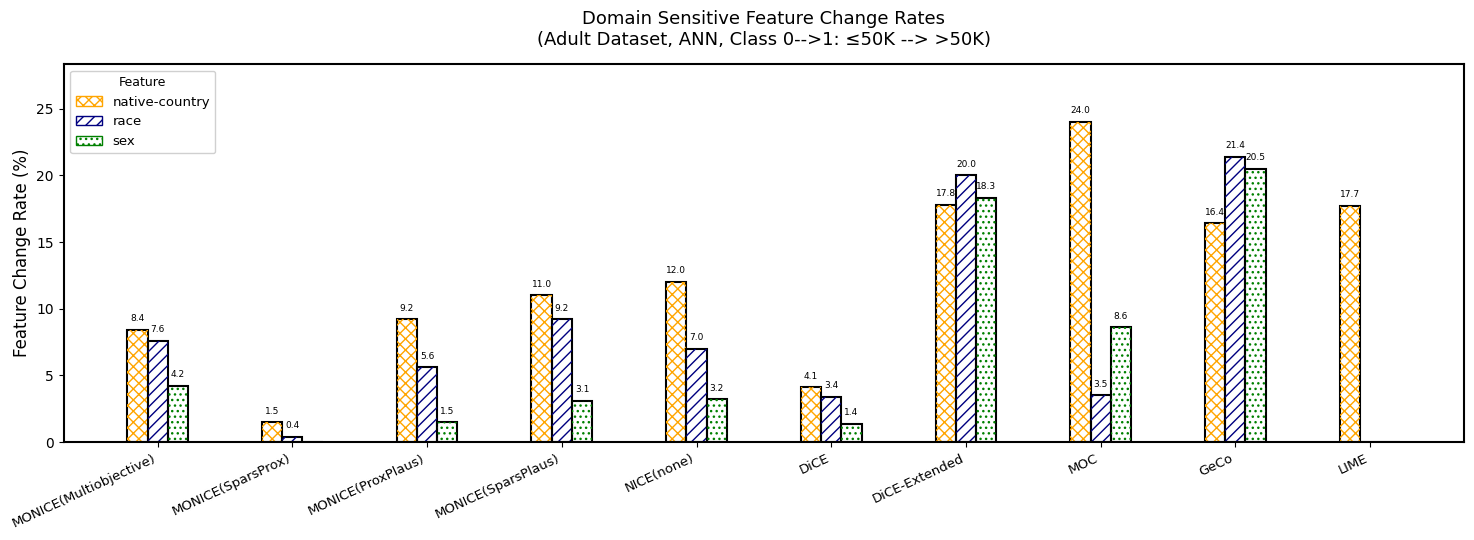

In [8]:

df_sens = df_key.loc[IMMUTABLE]
sensitive_sorted = df_sens.mean(axis=1).sort_values(ascending=False).index.tolist()
print("Sensitive features sorted:", sensitive_sorted)

feat_styles = {
    'native-country': {'edgecolor': 'orange', 'hatch': 'xxx'},
    'race':           {'edgecolor': 'navy', 'hatch': '///'},
    'sex':            {'edgecolor': 'green', 'hatch': '...'},
}

n_methods = len(KEY_METHODS)
n_feats   = len(sensitive_sorted)
x         = np.arange(n_methods)
width     = 0.15
offsets   = np.linspace(-(n_feats - 1) / 2, (n_feats - 1) / 2, n_feats) * width

fig, ax = plt.subplots(figsize=(15, 5.5))
fig.patch.set_facecolor('none')
ax.set_facecolor('none')
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color('black')
    spine.set_linewidth(1.5)

for i, feat in enumerate(sensitive_sorted):
    style = feat_styles[feat]
    vals  = df_all.loc[feat, KEY_METHODS].values.astype(float)
    pos   = x + offsets[i]

    ax.bar(pos, vals, width,
           facecolor='none', edgecolor='black', linewidth=1.5)
    bars = ax.bar(pos, vals, width,
                  facecolor='none', edgecolor=style['edgecolor'],
                  hatch=style['hatch'], linewidth=0)

    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.5,
                    f'{val:.1f}',
                    ha='center', va='bottom',
                    fontsize=6.5,
                    color='black')

ax.set_ylim(0, df_all.loc[sensitive_sorted, KEY_METHODS].max().max() * 1.18)
ymax = ax.get_ylim()[1]

ax.set_xticks(x)
ax.set_xticklabels(KEY_METHODS, fontsize=9.5, rotation=25, ha='right')
ax.set_ylabel('Feature Change Rate (%)', fontsize=12)
ax.set_title('Domain Sensitive Feature Change Rates\n'
             '(Adult Dataset, ANN, Class 0-->1: ≤50K --> >50K)',
             fontsize=13, pad=14)

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor='none',
                  edgecolor=feat_styles[f]['edgecolor'],
                  hatch=feat_styles[f]['hatch'])
    for f in sensitive_sorted
]
ax.legend(legend_handles, sensitive_sorted, fontsize=9.5, loc='upper left', framealpha=0.9,
          title='Feature', title_fontsize=9)

plt.tight_layout()
plt.show()

## Contrained Experiment

In [ ]:
# ============================================================
# Constrained MONICE Experiment — Adult, ANN
# ============================================================

from experiments.core.data_loader import TabularDataLoader
from experiments.core.path_utils import path_generator
from experiments.models.classification_trainer import SklearnTabularModeler
from experiments.models.autoencoder_trainer import AutoencoderTrainer
from monice import MONICE, AutoencoderPlausibility
import pickle
import numpy as np
from tqdm import tqdm
from time import time

DATASET_NAME = 'adult'
MODEL_NAME   = 'ANN'

paths = path_generator(DATASET_NAME, MODEL_NAME)
dataset = TabularDataLoader(paths['dataset'])
fn = dataset.feature_names
print(list(enumerate(fn)))  

# Constraint
IMMUTABLE_NAMES = ['sex', 'race', 'native-country']
MONOTONIC_NAMES  = {'age': 'increasing', 'education-num': 'increasing'}
EXCLUDE_NAMES = ['fnlwgt']  # census artifact, exclude from constrained exp

immutable_idx = [fn.index(f) for f in IMMUTABLE_NAMES]
monotonic_idx = {fn.index(f): d for f, d in MONOTONIC_NAMES.items()}
# fnlwgt: thêm vào immutable để MONICE không chỉnh sửa
exclude_idx = [fn.index(f) for f in EXCLUDE_NAMES]

all_immutable_idx = immutable_idx + exclude_idx  # sex, race, native-country, fnlwgt

print(f"Immutable indices: {[(i, fn[i]) for i in all_immutable_idx]}")
print(f"Monotonic indices: {[(fn[k], v) for k, v in monotonic_idx.items()]}")



[(0, 'age'), (1, 'fnlwgt'), (2, 'education-num'), (3, 'capital-gain'), (4, 'capital-loss'), (5, 'hours-per-week'), (6, 'workclass'), (7, 'education'), (8, 'marital-status'), (9, 'occupation'), (10, 'relationship'), (11, 'race'), (12, 'sex'), (13, 'native-country')]
Immutable indices: [(12, 'sex'), (11, 'race'), (13, 'native-country'), (1, 'fnlwgt')]
Monotonic indices: [('age', 'increasing'), ('education-num', 'increasing')]


In [10]:
# Load model & autoencoder
modeler = SklearnTabularModeler(DATASET_NAME, MODEL_NAME)
modeler.load()

autoencoder = AutoencoderTrainer(DATASET_NAME)
autoencoder.load()
plausibility_model = AutoencoderPlausibility(autoencoder)


# monice_constrained = MONICE(
#     X_train=dataset.X_train,
#     y_train=dataset.y_train,
#     predict_fn=lambda x: modeler.predict_proba(x),
#     plausibility_model=plausibility_model,
#     cat_feats=dataset.categorical_indices,
#     num_feats=dataset.continuous_indices,
#     integer_feats=None,
#     cost_weights=None,
#     immutable_features=all_immutable_idx,       # sex, race, native-country, fnlwgt
#     feature_bounds=None,
#     monotonic_constraints=monotonic_idx,         # age, education-num : increase
#     distance_metric='gower',
#     justified_cf=True,
#     eps=1e-6,
#     verbose=False
# )

# # exp
# results_constrained = []
# timeout_seconds = 300

# for row in tqdm(range(dataset.X_explain.shape[0]), desc='Constrained MONICE'):
#     x = dataset.X_explain[row:row + 1, :]
#     result = {'original': x}
#     try:
#         cf_dict = monice_constrained.explain(
#             X=x,
#             target_classes='other',
#             optimization=['robustness', 'sparsity', 'proximity', 'plausibility'],
#             k_nearest=5,
#             n_cfs=6,
#             numerical_steps=[0.2, 0.4, 0.6, 0.8, 1.0]
#         )
#         cf_key, cf_value = next(iter(cf_dict.items()))
#         result['cf']   = cf_value.counterfactual
#         result['time'] = cf_value.computation_time
#     except Exception as e:
#         print(f"[ERROR] Row {row}: {e}")
#         result['cf']   = np.tile(x, (6, 1))
#         result['time'] = 0
#     results_constrained.append(result)


# save_path = f'./data/{DATASET_NAME}/results/{MODEL_NAME}_monice_constrained.pkl'
# with open(save_path, 'wb') as f:
#     pickle.dump(results_constrained, f)
# print(f"Saved: {save_path}")

In [11]:
def check_violations(results, feature_names, immutable_names, monotonic_names, label=''):
    fn = feature_names
    viol = {f: 0 for f in immutable_names + list(monotonic_names.keys())}
    total_valid = 0
    
    for result in results:
        orig = result['original'].flatten()
        for cf in result['cf']:
            if np.any(np.isnan(cf)):
                continue
            # Check immutable
            for f in immutable_names:
                if orig[fn.index(f)] != cf[fn.index(f)]:
                    viol[f] += 1
            # Check monotonic
            for f, direction in monotonic_names.items():
                idx = fn.index(f)
                if direction == 'increasing' and cf[idx] < orig[idx]:
                    viol[f] += 1
                elif direction == 'decreasing' and cf[idx] > orig[idx]:
                    viol[f] += 1
            total_valid += 1
    
    print(f"\n{'='*50}")
    print(f"  {label} - Violation Rates (over {total_valid} valid CFs)")
    print(f"{'='*50}")
    for f, count in viol.items():
        print(f"  {f:20s}: {count:4d} / {total_valid} = {count/max(total_valid,1)*100:.1f}%")

# Load unconstrained (existing)
with open(f'./data/adult/results/ANN_monicemultiobjectivegower.pkl', 'rb') as f:
    results_unc = pickle.load(f)

with open(f'./data/adult/results/ANN_monice_constrained.pkl', 'rb') as f:
    results_con = pickle.load(f)
    
check_violations(results_unc, fn, 
                 IMMUTABLE_NAMES, MONOTONIC_NAMES, 
                 label='Unconstrained MONICE')

check_violations(results_con, fn, 
                 IMMUTABLE_NAMES, MONOTONIC_NAMES, 
                 label='Constrained MONICE')


  Unconstrained MONICE - Violation Rates (over 1200 valid CFs)
  sex                 :   40 / 1200 = 3.3%
  race                :   76 / 1200 = 6.3%
  native-country      :   87 / 1200 = 7.2%
  age                 :  255 / 1200 = 21.2%
  education-num       :   83 / 1200 = 6.9%

  Constrained MONICE - Violation Rates (over 1200 valid CFs)
  sex                 :    0 / 1200 = 0.0%
  race                :    0 / 1200 = 0.0%
  native-country      :    0 / 1200 = 0.0%
  age                 :    0 / 1200 = 0.0%
  education-num       :    0 / 1200 = 0.0%


                    Domain  Unconstrained (%)  Constrained (%)
capital-gain    Actionable               94.8             96.4
hours-per-week  Actionable               50.5             48.0
fnlwgt          Actionable               46.7              0.0
occupation      Actionable               31.2             34.6
education       Actionable               13.3             17.0
workclass       Actionable                8.8             10.0
capital-loss    Actionable                3.2              3.2
marital-status  Actionable               20.0             24.7
relationship    Actionable               20.0             23.6
age              Monotonic               62.8             62.3
education-num    Monotonic               18.4             23.7
sex              Immutable                4.2              0.0
race             Immutable                7.6              0.0
native-country   Immutable                8.4              0.0


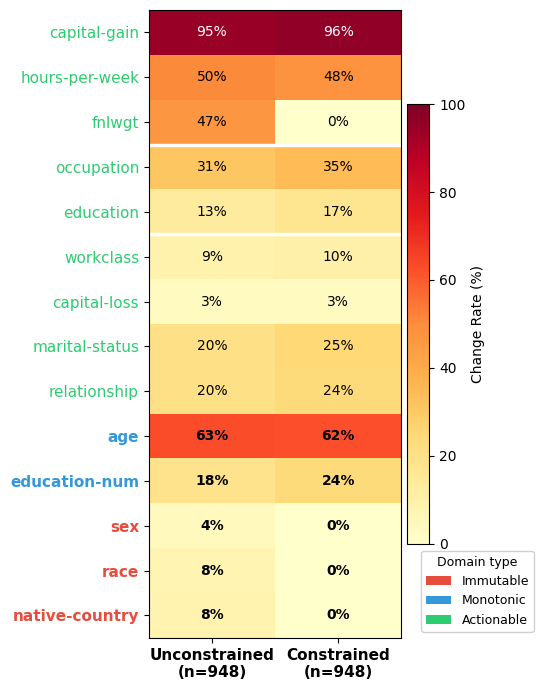

In [ ]:
def domain_label(feat):
    if feat in IMMUTABLE:  return 'Immutable'
    if feat in MONOTONIC:  return 'Monotonic'
    return 'Actionable'

def domain_color(feat):
    if feat in IMMUTABLE: return '#e74c3c'
    if feat in MONOTONIC: return '#3498db'
    return '#2ecc71'

def compute_rates(results, fn, modeler):
    counts = np.zeros(len(fn))
    total  = 0
    for r in results:
        orig      = r['original'].flatten()
        orig_pred = modeler.predict_proba(orig.reshape(1,-1)).argmax()
        if orig_pred != 0:
            continue    
        for cf in r['cf']:
            if np.any(np.isnan(cf)):
                continue
            if modeler.predict_proba(cf.reshape(1,-1)).argmax() != 1:
                continue
            counts += (cf != orig).astype(int)
            total  += 1
    return pd.Series(counts / max(total,1) * 100, index=fn), total

rates_unc, n_unc = compute_rates(results_unc, fn, modeler)
rates_con, n_con = compute_rates(results_con, fn, modeler)

DISPLAY_ORDER =  ACTIONABLE + MONOTONIC + IMMUTABLE
df_compare = pd.DataFrame({
    'Domain': [domain_label(f) for f in DISPLAY_ORDER],
    'Unconstrained (%)': rates_unc[DISPLAY_ORDER].round(1).values,
    'Constrained (%)': rates_con[DISPLAY_ORDER].round(1).values,
}, index=DISPLAY_ORDER)

print(df_compare.to_string())


Z = df_compare[['Unconstrained (%)', 'Constrained (%)']].values  # (n_feats, 2)

fig, ax = plt.subplots(figsize=(6, 7))

im = ax.imshow(Z, cmap='YlOrRd', aspect='auto', vmin=0, vmax=100)

# Axes
ax.set_xticks([0, 1])
ax.set_xticklabels([
    f'Unconstrained\n(n={n_unc})',
    f'Constrained\n(n={n_con})'
], fontsize=11, fontweight='bold')

ax.set_yticks(range(len(DISPLAY_ORDER)))
yticklabels = ax.set_yticklabels(DISPLAY_ORDER, fontsize=11)
for lbl in yticklabels:
    lbl.set_color(domain_color(lbl.get_text()))
    if lbl.get_text() in IMMUTABLE + MONOTONIC:
        lbl.set_fontweight('bold')

# Cell annotations
for i, feat in enumerate(DISPLAY_ORDER):
    for j in range(2):
        val = Z[i, j]
        txt_color = 'white' if val >= 65 else 'black'
        weight    = 'bold' if feat in IMMUTABLE + MONOTONIC else 'normal'
        ax.text(j, i, f'{val:.0f}%', ha='center', va='center',
                fontsize=10, color=txt_color, fontweight=weight)

for sep in [len(IMMUTABLE) - 0.5, len(IMMUTABLE) + len(MONOTONIC) - 0.5]:
    ax.axhline(sep, color='white', linewidth=2.5, linestyle='-')

# Colorbar
plt.colorbar(im, ax=ax, label='Change Rate (%)', shrink=0.7, pad=0.02)

# ax.set_title('Feature Change Rates: Before and After\nDomain Constraint Enforcement\n'
#              '(Adult, ANN, Class 0-->1: ≤50K → >50K)',
#              fontsize=12, pad=12)

# Legend
legend_handles = [
    Patch(facecolor='#e74c3c', label='Immutable'),
    Patch(facecolor='#3498db', label='Monotonic'),
    Patch(facecolor='#2ecc71', label='Actionable'),
]
ax.legend(handles=legend_handles, fontsize=9,
          loc='lower right', bbox_to_anchor=(1.55, 0),
          framealpha=0.9, title='Domain type', title_fontsize=9)

plt.tight_layout()

plt.show()


In [19]:
print(len(results_unc))

200


In [13]:
import pandas as pd
import pickle
import numpy as np
from experiments.core.data_fetcher import OpenMLFetcher
from experiments.core.data_loader import TabularDataLoader
import warnings

warnings.filterwarnings('ignore')

def print_output(dataset: str, model: str, cf: str, constraint: bool, index: int = 0):
    # Load data and output
    data = TabularDataLoader(f'./data/{dataset}/data.pkl')
    if constraint:
        with open(f'./data/{dataset}/results/{model}_monice_constrained.pkl', 'rb') as f:
            output = pickle.load(f)
    else:
        with open(f'./data/{dataset}/results/{model}_{cf}.pkl', 'rb') as f:
            output = pickle.load(f)

    feature_names = data.feature_names
    target_name = data.metadata['target_attribute']

    # Create feature encoding info
    feature_encoding_info = {}
    for feature in feature_names:
        try:
            raw_mapping = data.metadata['label_encoders'][feature]['values_mappings']
            feature_encoding_info[feature] = dict(raw_mapping)
        except:
            pass

    reverse_feature_encoding_info = {
        feature: {v: k for k, v in mapping.items()}
        for feature, mapping in feature_encoding_info.items()
    }

    target_mapping = data.metadata['target_encoder']['values_mappings']
    reverse_target_mapping = {v: k for k, v in target_mapping}

    # Create original DataFrame
    df_original = pd.DataFrame(columns=feature_names + [target_name])
    for i in range(len(feature_names)):
        feature = feature_names[i]
        value = data.X_explain[index][i]
        df_original.loc[0, feature] = value

        if feature in reverse_feature_encoding_info:
            try:
                df_original.loc[0, feature] = reverse_feature_encoding_info[feature][int(value)]
            except:
                pass

    target_value = data.y_explain[index]
    df_original.loc[0, target_name] = reverse_target_mapping[target_value]

    # Create list of counterfactuals
    rows = []
    rows_diff = []
    for cf_instance in output[index]['cf']:
        row = {}
        row_diff = {}
        for j in range(len(feature_names)):
            feature = feature_names[j]
            value = cf_instance[j]
            if feature in reverse_feature_encoding_info:
                try:
                    value_decoded = reverse_feature_encoding_info[feature][int(value)]
                except:
                    value_decoded = value
            else:
                value_decoded = value
            row[feature] = value_decoded

            # Compare with original
            orig_val = df_original.loc[0, feature]
            if value_decoded != orig_val:
                row_diff[feature] = value_decoded
            else:
                row_diff[feature] = '-'
        target_val = 0 if target_value == 1 else 1
        target_decoded = reverse_target_mapping[target_val]
        row[target_name] = target_decoded

        # Compare target
        if target_decoded != df_original.loc[0, target_name]:
            row_diff[target_name] = target_decoded
        else:
            row_diff[target_name] = '-'

        rows.append(row)
        rows_diff.append(row_diff)

    df_cfs = pd.DataFrame(rows, columns=feature_names + [target_name])
    df_cfs_diff = pd.DataFrame(rows_diff, columns=feature_names + [target_name])

    return df_original, df_cfs_diff

In [14]:
df_original, ann_gower = print_output('adult','ANN', 'monicemultiobjectivegower',False, 20)
_, ann_gower_constrained = print_output('adult','ANN', 'monicemultiobjectivegower', True, 20)

In [15]:
df_original

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass,education,marital-status,occupation,relationship,race,sex,native-country,class
0,46.0,211226.0,12.0,0.0,0.0,36.0,Private,Assoc-acdm,Married-civ-spouse,Transport-moving,Husband,Other,Male,United-States,<=50K


In [16]:
ann_gower

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass,education,marital-status,occupation,relationship,race,sex,native-country,class
0,42.0,191783.0,-,-,-,40.0,-,-,-,Prof-specialty,-,White,-,-,>50K
1,44.0,212509.0,-,-,-,40.0,-,-,-,Prof-specialty,-,-,-,-,>50K
2,45.0,233511.0,-,-,-,40.0,-,-,-,Prof-specialty,-,White,-,-,>50K
3,-,-,-,-,-,-,-,-,-,Exec-managerial,-,-,-,-,>50K
4,-,224597.0,-,-,-,-,-,-,-,Exec-managerial,-,-,-,-,>50K
5,-,233511.0,-,-,-,40.0,-,-,-,Exec-managerial,-,White,-,-,>50K


In [17]:
ann_gower_constrained

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,workclass,education,marital-status,occupation,relationship,race,sex,native-country,class
0,-,-,-,-,-,-,-,-,-,Exec-managerial,-,-,-,-,>50K
1,-,-,-,38.0,-,38.0,-,-,-,Prof-specialty,-,-,-,-,>50K
2,-,-,-,2335.0,-,-,-,-,-,-,-,-,-,-,>50K
3,-,-,-,3503.0,-,40.0,-,-,-,Prof-specialty,-,-,-,-,>50K
4,48.0,-,-,7298.0,-,37.0,-,-,-,-,-,-,-,-,>50K
5,48.0,-,-,7298.0,-,40.0,-,-,-,Exec-managerial,-,-,-,-,>50K
